<a href="https://colab.research.google.com/github/akashg9705/colab_proj/blob/main/netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.


In [ ]:
print("Dataset path:", path)

Dataset path: /kaggle/input/netflix-shows


Load CSV

In [ ]:
import os
import pandas as pd
csv_file = os.path.join(path, "netflix_titles.csv")
df = pd.read_csv(csv_file)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.head()

Shape: (8807, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows:
0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


summary


In [ ]:
import numpy as np

In [ ]:
print("\n5-LINE DATA SUMMARY:")
summary_lines = [
    f"1. The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.",
    "2. It includes Netflix titles such as movies and TV shows.",
    "3. Key columns include title, director, cast, country, date_added, release_year, rating, duration, and genre.",
    "4. Several columns have missing values, especially director, cast, and country.",
    "5. This dataset can be used to study content type, country distribution, release trends, ratings, and genres."
]
for line in summary_lines:
    print(line)


5-LINE DATA SUMMARY:
1. The dataset contains 8807 rows and 12 columns.
2. It includes Netflix titles such as movies and TV shows.
3. Key columns include title, director, cast, country, date_added, release_year, rating, duration, and genre.
4. Several columns have missing values, especially director, cast, and country.
5. This dataset can be used to study content type, country distribution, release trends, ratings, and genres.


Clean

In [ ]:
clean_df = df.copy()
clean_df = clean_df.drop_duplicates()
bad_rating_mask = clean_df["rating"].astype(str).str.fullmatch(r"\d+\s*min", na=False)
clean_df.loc[bad_rating_mask, "duration"] = clean_df.loc[bad_rating_mask, "rating"]
clean_df.loc[bad_rating_mask, "rating"] = np.nan
clean_df["date_added"] = pd.to_datetime(clean_df["date_added"], errors="coerce")

for col in ["director", "cast", "country"]:
    clean_df[col] = clean_df[col].fillna("Unknown")

clean_df["rating"] = clean_df["rating"].fillna("Unknown")
clean_df = clean_df.dropna(subset=["date_added"]).copy()
clean_df["date_added_year"] = clean_df["date_added"].dt.year
clean_df["date_added_month"] = clean_df["date_added"].dt.month_name()
clean_df["title_length"] = clean_df["title"].str.len()

In [ ]:
clean_df["duration_min"] = clean_df["duration"].str.extract(r"(\d+)").astype(float)
clean_df["cast_count"] = (
    clean_df["cast"]
    .replace("Unknown", np.nan)
    .str.split(",")
    .apply(lambda x: len(x) if isinstance(x, list) else np.nan)
)
clean_df["genre_count"] = clean_df["listed_in"].str.split(",").apply(len)
analysis_df = clean_df.drop(columns=["show_id", "description"])

print("\nCLEANED DATA SHAPE:", analysis_df.shape)
print("\nMISSING VALUES AFTER CLEANING:")
print(analysis_df.isnull().sum())

print("\nCLEANED DATA PREVIEW:")
display(analysis_df.head())


CLEANED DATA SHAPE: (8709, 16)

MISSING VALUES AFTER CLEANING:
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
duration              0
listed_in             0
date_added_year       0
date_added_month      0
title_length          0
duration_min          0
cast_count          817
genre_count           0
dtype: int64

CLEANED DATA PREVIEW:


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,title_length,duration_min,cast_count,genre_count
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,September,20,90.0,NaN,1
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021,September,13,2.0,19.0,3
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,September,9,1.0,9.0,3
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021,September,21,1.0,NaN,2
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021,September,12,2.0,8.0,3


EDA

In [ ]:
# Q1: Which type of content is more common?
print("\nQ1. Content Type Distribution")
print(analysis_df["type"].value_counts())

# Q2: Which countries produce the most Netflix content?
print("\nQ2. Top 10 Countries")
print(analysis_df["country"].value_counts().head(10))

# Q3: Which ratings are most common?
print("\nQ3. Rating Distribution")
print(analysis_df["rating"].value_counts())

# Q4: What does the numeric data look like?
print("\nQ4. Descriptive Statistics")
display(analysis_df[["release_year", "duration_min", "title_length", "cast_count", "genre_count"]].describe())

# Q5: In which year did Netflix add the most titles?
print("\nQ5. Titles Added Per Year (Top 10)")
print(analysis_df.groupby("date_added_year")["title"].count().sort_values(ascending=False).head(10))


Q1. Content Type Distribution
type
Movie      6131
TV Show    2578
Name: count, dtype: int64

Q2. Top 10 Countries
country
United States     2778
India              971
Unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64

Q3. Rating Distribution
rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
Unknown        7
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

Q4. Descriptive Statistics


,release_year,duration_min,title_length,cast_count,genre_count
count,8709.000000,8709.000000,8709.000000,7892.000000,8709.000000
mean,2014.197038,70.592031,17.754851,8.039027,2.195430
std,8.826219,50.602272,10.657472,4.472702,0.784216
min,1925.000000,1.000000,1.000000,1.000000,1.000000
25%,2013.000000,3.000000,10.000000,6.000000,2.000000
50%,2017.000000,89.000000,15.000000,8.000000,2.000000
75%,2019.000000,106.000000,23.000000,10.000000,3.000000
max,2021.000000,312.000000,104.000000,50.000000,3.000000



Q5. Titles Added Per Year (Top 10)
date_added_year
2019    1999
2020    1878
2018    1625
2021    1498
2017    1164
2016     418
2015      73
2014      23
2011      13
2013      10
Name: title, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Visualization


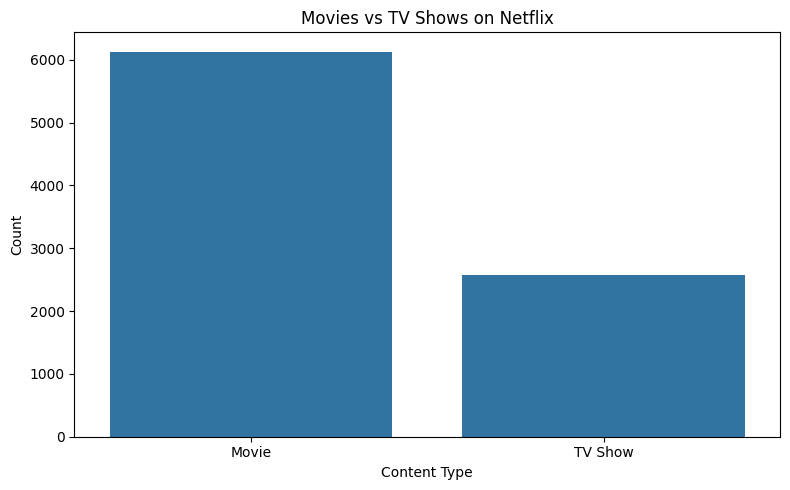

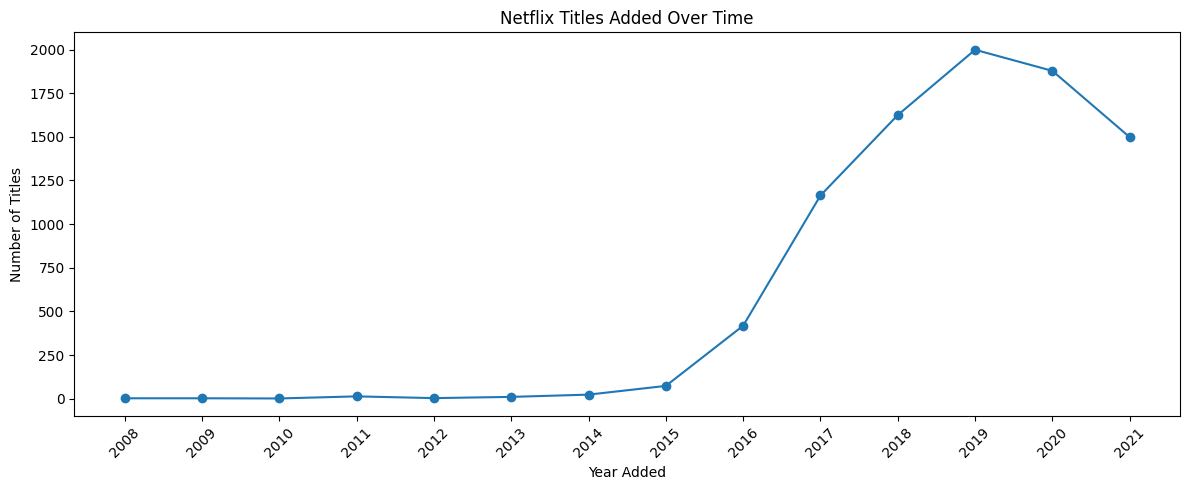

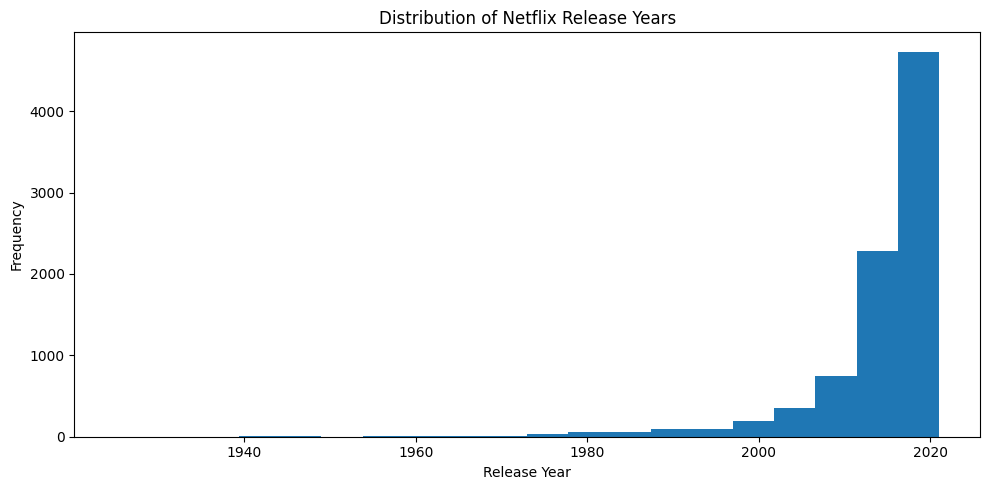

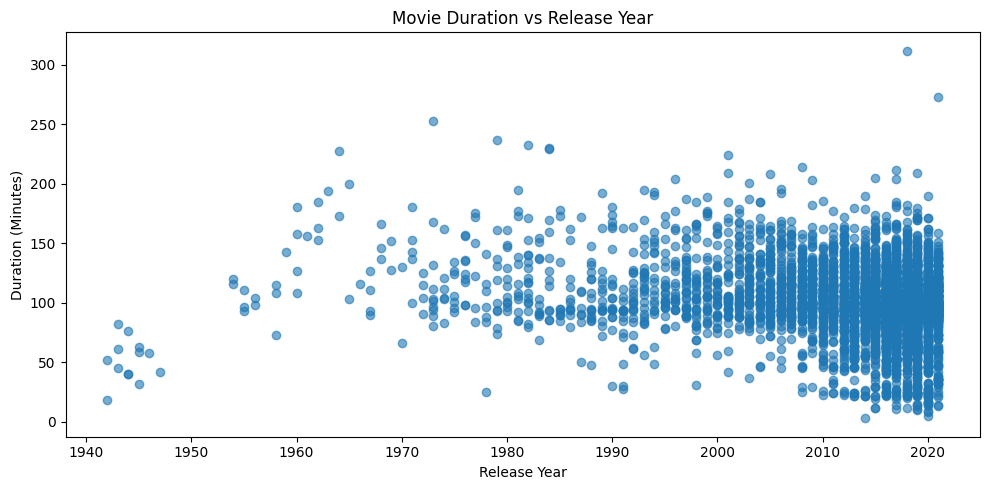

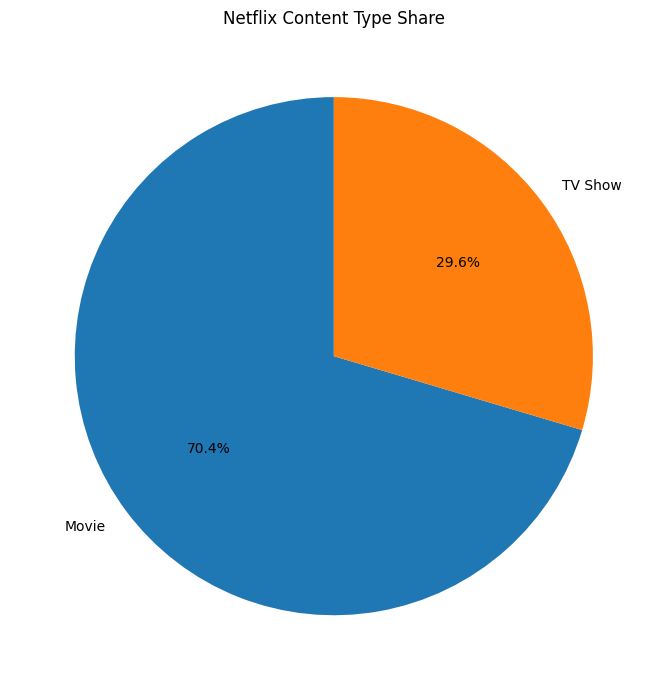

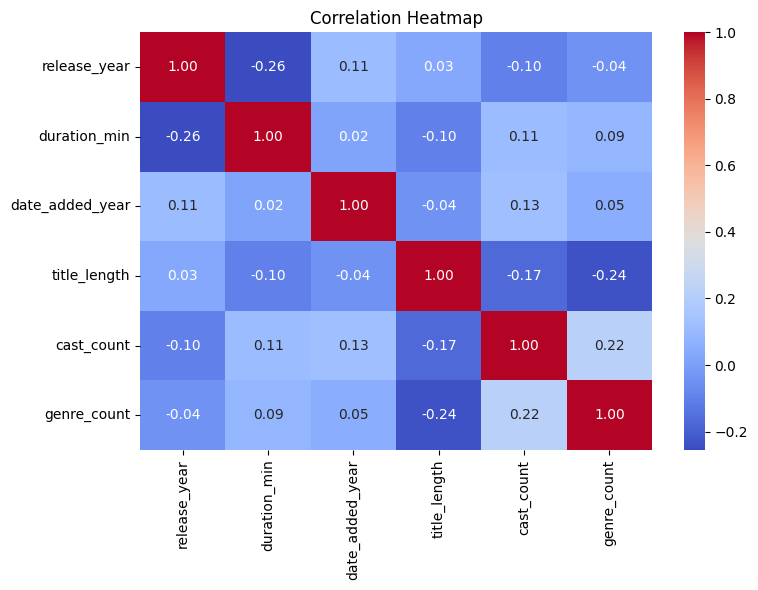

In [ ]:
# 1) Bar Chart — Movies vs TV Shows
plt.figure(figsize=(8, 5))
type_counts = analysis_df["type"].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Line Chart — Titles Added Over Time
plt.figure(figsize=(12, 5))
year_counts = analysis_df["date_added_year"].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Netflix Titles Added Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(year_counts.index, rotation=45)
plt.tight_layout()
plt.show()

# 3) Histogram — Release Year Distribution
plt.figure(figsize=(10, 5))
plt.hist(analysis_df["release_year"], bins=20)
plt.title("Distribution of Netflix Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4) Scatter Plot — Movie Duration vs Release Year
movie_df = analysis_df[analysis_df["type"] == "Movie"].copy()

plt.figure(figsize=(10, 5))
plt.scatter(movie_df["release_year"], movie_df["duration_min"], alpha=0.6)
plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.tight_layout()
plt.show()

# 5) Pie Chart — Share of Content Types
plt.figure(figsize=(7, 7))
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Netflix Content Type Share")
plt.tight_layout()
plt.show()

# 6) Heatmap — Correlation of Numeric Features
heatmap_df = analysis_df[["release_year", "duration_min", "date_added_year", "title_length", "cast_count", "genre_count"]].copy()
heatmap_df = heatmap_df.fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Insights


In [ ]:
movie_pct = analysis_df["type"].value_counts(normalize=True).get("Movie", 0) * 100
tv_pct = analysis_df["type"].value_counts(normalize=True).get("TV Show", 0) * 100
top_country = analysis_df["country"].value_counts().idxmax()
top_country_count = analysis_df["country"].value_counts().max()
top_rating = analysis_df["rating"].value_counts().idxmax()
peak_add_year = analysis_df["date_added_year"].value_counts().idxmax()
peak_release_year = analysis_df["release_year"].value_counts().idxmax()
avg_movie_duration = movie_df["duration_min"].mean()

print("\nINSIGHTS REPORT")
print(f"1. Movies dominate the catalog, making up {movie_pct:.1f}% of titles, while TV Shows account for {tv_pct:.1f}%.")
print(f"2. The United States contributes the most titles with {top_country_count} entries, showing it is Netflix's largest content source.")
print(f"3. TV-MA is the most common rating, which suggests Netflix strongly caters to mature audiences.")
print(f"4. Netflix added the most titles in {peak_add_year}, which is visible in the line chart of titles added over time.")
print(f"5. The most common release year is {peak_release_year}, and the average movie duration is about {avg_movie_duration:.1f} minutes.")


INSIGHTS REPORT
1. Movies dominate the catalog, making up 70.4% of titles, while TV Shows account for 29.6%.
2. The United States contributes the most titles with 2778 entries, showing it is Netflix's largest content source.
3. TV-MA is the most common rating, which suggests Netflix strongly caters to mature audiences.
4. Netflix added the most titles in 2019, which is visible in the line chart of titles added over time.
5. The most common release year is 2018, and the average movie duration is about 99.6 minutes.
